# 1D TV denoising: method comparison

This notebook checks all current 1D TV denoising methods in this repo:

1. Condat v1 direct 1D TV solver,
2. Condat v2 direct 1D TV solver,
3. ProxTV.jl reference solver,
4. TVDenoise.jl `tvd` sparse-ADMM solver,
5. weighted Kamilov one-pass shrinkage,
6. weighted Kamilov FPPA diagnostic experiment.

The main exact-reference comparison is Condat v1/v2, ProxTV.jl, and TVDenoise.jl. The Kamilov one-pass method is kept here because it is the method we are debugging; it does not match exact 1D TV yet.


## Weighted 1-norm proximal operator

For a scalar coefficient `z_j`, the weighted regularizer is

$$R(z) = \lambda \sum_j w_j |z_j|,$$

where `w_j` is either 0 or 1. The proximal problem separates over coefficients:

$$\operatorname{prox}_{R}(z_j) = \arg\min_u \frac{1}{2}(u-z_j)^2 + \lambda w_j |u|.$$

The solution is weighted soft-thresholding:

$$\operatorname{prox}_{R}(z_j) = \operatorname{sign}(z_j)\max(|z_j| - \lambda w_j, 0).$$

Therefore:

- if `w_j = 1`, shrink the coefficient toward zero;
- if `w_j = 0`, leave the coefficient unchanged.

For non-circular 1D TV, the wrap-around difference should not be penalized, so the wrap coefficient uses weight 0.

In [29]:
using Random, LinearAlgebra, Printf, Plots
using ProxTV
using TVDenoise

include("src/tv1d_condat_v1.jl")
include("src/tv1d_condat_v2.jl")
include("src/tv1d_kamilov.jl")

function proxtv_1d(y, λ)
    h = NormTVp(λ, 1.0, length(y))
    x = similar(y, Float64)
    prox!(x, h, y, 1.0)
    return x
end


proxtv_1d (generic function with 1 method)

In [30]:
Random.seed!(7)

N = 200
xtrue = vcat(fill(0.0, 45), fill(2.0, 45), fill(-1.0, 55), fill(1.0, 55))
y = xtrue + 0.35 * randn(N)
λ = 1.2

rmse(x, y) = norm(x - y) / sqrt(length(x))
tv1_value(x) = sum(abs.(diff(x)))

tv1_value (generic function with 1 method)

In [31]:
x_condat_v1 = similar(y)
x_condat_v2 = similar(y)
x_kamilov_onepass = similar(y)

tv1d_condat_v1!(x_condat_v1, y, λ)
tv1d_condat_v2!(x_condat_v2, y, λ)
x_proxtv = proxtv_1d(y, λ)

# TVDenoise.jl sparse ADMM comparison.
# This is the 1D path of TVDenoise.tvd, using non-circular first-difference TV.
ρ_tvd = 5.0
x_tvd, hist_tvd = tvd(y, λ, ρ_tvd; maxit=10000, tol=1e-8, verbose=false)

tv1d_kamilov_denoise!(x_kamilov_onepass, y, λ)

# Diagnostic only: the paper's general FPPA form.
# This is not the main non-iterative Kamilov formula and is not exact Condat TV.
gammas = [0.0005, 0.0001, 0.00005, 0.0000317, 0.00001, 0.000005]
x_kamilov_fppa = Dict(γ => tv1d_kamilov_fppa(y, λ; γ=γ, maxiter=200000) for γ in gammas)

println("Condat v1 vs v2: ", norm(x_condat_v1 - x_condat_v2, Inf))
println("ProxTV.jl vs Condat: ", norm(x_proxtv - x_condat_v1, Inf))
println("TVDenoise.jl tvd vs Condat: ", norm(x_tvd - x_condat_v1, Inf),
        "  iterations=", hist_tvd.k, "  rho=", ρ_tvd)
println("One-pass weighted Kamilov vs Condat: ", norm(x_kamilov_onepass - x_condat_v1, Inf))
for γ in gammas
    x = x_kamilov_fppa[γ]
    println("FPPA γ=", γ, ": inf error=", norm(x - x_condat_v1, Inf), ", rmse=", rmse(x, x_condat_v1))
end


Condat v1 vs v2: 1.3322676295501878e-15
ProxTV.jl vs Condat: 1.1102230246251565e-16
TVDenoise.jl tvd vs Condat: 1.0301186125216688e-6  iterations=343  rho=5.0
One-pass weighted Kamilov vs Condat: 0.7139299169902438
FPPA γ=0.0005: inf error=0.014156661166093577, rmse=0.004743542359177703
FPPA γ=0.0001: inf error=0.0029874666931149485, rmse=0.0008798717056907177
FPPA γ=5.0e-5: inf error=0.0015044059390760187, rmse=0.00042362790043540445
FPPA γ=3.17e-5: inf error=0.0009563054807899263, rmse=0.00028965814392802546
FPPA γ=1.0e-5: inf error=0.0192369028488808, rmse=0.008282234796998161
FPPA γ=5.0e-6: inf error=0.11892487392095852, rmse=0.035968226686627656


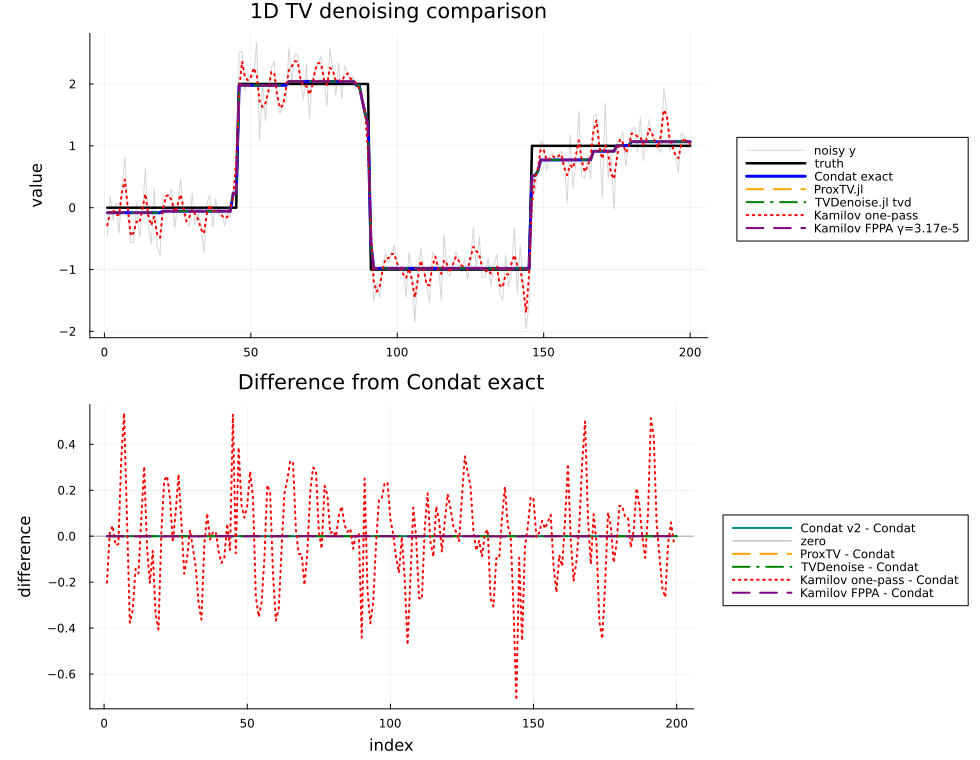

In [32]:
mkpath("figures")

γ_plot = 0.0000317
x_fppa_plot = x_kamilov_fppa[γ_plot]

# Top panel: keep the signal readable. The exact/reference methods nearly overlap,
# so use distinct line styles and put the legend outside the plotting area.
p_signal = plot(
    y;
    label="noisy y",
    color=:gray70,
    alpha=0.55,
    linewidth=1,
    title="1D TV denoising comparison",
    ylabel="value",
    legend=:outerright,
    size=(920, 620),
)
plot!(p_signal, xtrue; label="truth", color=:black, linewidth=2.5)
plot!(p_signal, x_condat_v1; label="Condat exact", color=:blue, linewidth=3)
plot!(p_signal, x_proxtv; label="ProxTV.jl", color=:orange, linewidth=2, linestyle=:dash)
plot!(p_signal, x_tvd; label="TVDenoise.jl tvd", color=:green, linewidth=2, linestyle=:dashdot)
plot!(p_signal, x_kamilov_onepass; label="Kamilov one-pass", color=:red, linewidth=2, linestyle=:dot)
plot!(p_signal, x_fppa_plot; label="Kamilov FPPA γ=$(γ_plot)", color=:purple, linewidth=2, linestyle=:dash)

# Bottom panel: compare differences from Condat directly.
# This makes overlapping exact methods and Kamilov errors visible without cluttering the signal.
p_error = plot(
    x_condat_v2 .- x_condat_v1;
    label="Condat v2 - Condat",
    color=:cyan4,
    linewidth=2,
    title="Difference from Condat exact",
    xlabel="index",
    ylabel="difference",
    legend=:outerright,
    size=(920, 620),
)
hline!(p_error, [0.0]; label="zero", color=:black, linewidth=1, linestyle=:solid, alpha=0.35)
plot!(p_error, x_proxtv .- x_condat_v1; label="ProxTV - Condat", color=:orange, linewidth=2, linestyle=:dash)
plot!(p_error, x_tvd .- x_condat_v1; label="TVDenoise - Condat", color=:green, linewidth=2, linestyle=:dashdot)
plot!(p_error, x_kamilov_onepass .- x_condat_v1; label="Kamilov one-pass - Condat", color=:red, linewidth=2, linestyle=:dot)
plot!(p_error, x_fppa_plot .- x_condat_v1; label="Kamilov FPPA - Condat", color=:purple, linewidth=2, linestyle=:dash)

p = plot(p_signal, p_error; layout=(2, 1), size=(980, 760), left_margin=6Plots.mm)
savefig(p, "figures/main1d_signal.png")
p


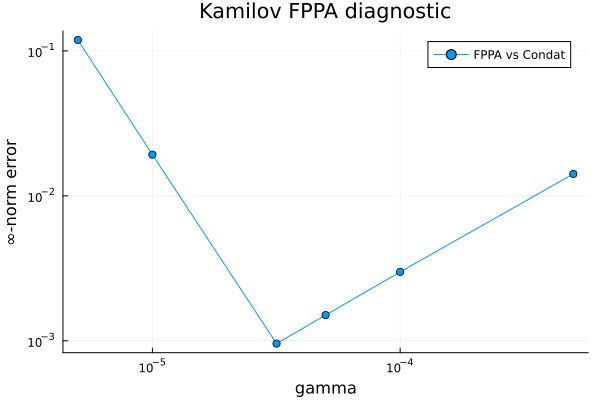

In [28]:
errs = [norm(x_kamilov_fppa[γ] - x_condat_v1, Inf) for γ in gammas]
p2 = plot(gammas, errs, xscale=:log10, yscale=:log10, marker=:circle,
          label="FPPA vs Condat", title="Kamilov FPPA diagnostic",
          xlabel="gamma", ylabel="∞-norm error")
savefig(p2, "figures/main1d_gamma_error.png")
p2